# 深度學習與金融應用｜Unit 1
# 神經網路基礎與訓練流程

**教師版(含解答與藍框註解)**

---

這是深度學習課程的第一堂課,接續你上過的 sklearn 機器學習課。

**上完這一課,你會**
1. 知道深度學習到底在做什麼,以及它和你熟悉的 sklearn 差在哪
2. 用直覺(不背數學公式)搞懂幾個名詞:神經元、激活函數、損失函數、梯度下降
3. 看懂 Epoch、Batch、Learning Rate 這三個訓練時要設定的數字是什麼意思
4. 自己用 Keras 走完一輪:建立模型 → 訓練 → 打分數 → 存檔
5. 把訓練過程畫成圖,一眼看出模型有沒有越學越好
6. 認識 Colab 的 CPU / GPU / TPU,知道什麼時候該切換

**我們拿什麼來練習**:台積電(2330)的股價。題目是「明天股價會大幅波動,還是小幅波動?」——「今天大波動、明天通常也大波動」這種群聚現象確實存在,但很微弱;所以我們會<b>誠實面對</b>「模型其實很難贏過一個簡單猜法」這件事。(猜「明天漲還是跌」更慘,幾乎就是丟銅板。)

**大約上課時數**:10 小時

<div style="background-color:#e3f2fd;border-left:5px solid #1976d2;padding:12px 16px;margin:8px 0;border-radius:4px;color:#1a1a1a;"><b>🧑‍🏫本單元定位</b><br>這是學生第一次接觸深度學習框架。教學重點<b>不是</b>做出高準確率模型,而是讓學生把注意力放在「觀念」與「流程」。金融案例選擇隔日<b>波動率大小</b>——波動確實會<b>群聚</b>(自相關為正),學理上比漲跌方向好預測。<b>但要對學生誠實:</b>在每日資料、小模型、單一測試集下,這個訊號弱到模型仍然贏不過樸素 baseline;而且當測試期比訓練期更波動(regime 漂移),固定門檻會讓 baseline 假性偏強、更難打敗。<br>這正是本單元的核心:<b>市場很難預測(深度學習不是印鈔機),而『baseline 怎麼定義、資料有沒有 regime 漂移』會大大影響你對模型的判斷</b>——這比追高準確率重要得多。</div>

---
## 第 0 節　先認識你的運算工具(Colab)

深度學習要算的東西非常多。這一節先認識我們拿來「算」的硬體(CPU、GPU),並學會在 Colab 裡切換它們。

<div style="background-color:#e3f2fd;border-left:5px solid #1976d2;padding:12px 16px;margin:8px 0;border-radius:4px;color:#1a1a1a;"><b>🧑‍🏫 教師註解｜上課環境說明</b><br>本課程以 <b>Google Colab</b> 為預設環境,原因是:免安裝、環境統一、且免費就有 T4 GPU 可用。學生不論用 Windows、Mac 或輕薄筆電,只要能開瀏覽器,體驗完全一致(運算實際發生在 Google 雲端)。</div>

In [121]:
# 訓練環境的檢查
import tensorflow as tf

print(f'TensorFlow 版本: {tf.__version__}')

groups = tf.config.list_physical_devices('GPU')
if groups:
  print(f'目前有GPU可用')
else:
  print(f'目前是CPU可用')

TensorFlow 版本: 2.20.0
目前是CPU可用


### 想換 CPU 或 GPU,怎麼切?

在 Colab 最上面的選單點:**執行階段 → 變更執行階段類型 → 硬體加速器**,就能選:

| 選項 | 說明 | 本課程用途 |
|---|---|---|
| **CPU** | 沒有加速器 | U1、U2 的對照組 |
| **T4 GPU** | 免費就能用的 GPU | U3、U5 的 GPU 加速主力 |
| **v5e-1 TPU** | 免費就能用的 TPU | 只當延伸知識,本課不實作 |
| 其他 GPU/TPU | 灰色的是付費選項 | 教學用不到 |

---
## 第 1 節　從 sklearn 到 Keras:神經網路到底在做什麼?

先別被「深度學習」「神經網路」這些名詞嚇到。它做的事,其實跟你在 ML 課做的一模一樣:

**丟給模型一堆資料,讓它自己找出「輸入」和「答案」之間的關係。**

在 ML 課,你寫 `model.fit(X, y)`,sklearn 就幫你把這個關係學好了。深度學習也是寫 `model.fit(X, y)`,只是中間那個 model 換了一種——換成**神經網路**。

那神經網路特別在哪?打個比方:

- sklearn 的邏輯回歸,像請**一位老師**直接看資料、給答案。
- 神經網路,則像把資料交給**一排一排的老師接力**:第一排先把資料整理成一些「線索」傳給第二排;第二排再從這些線索整理出更進階的線索……最後一排才根據所有線索給出預測(例如「明天大波動的機率是 0.7」)。

而每一排(我們叫它一個「**層**」)做的事,其實只有兩步:**把數字乘一乘、加一加(矩陣乘法),再壓一下(激活函數)**。就這樣一層一層傳下去,神經網路就能學到比單一老師更複雜的規律。

下一節,我們就親手用最簡單的算式,把這個「一層一層傳下去」跑一次給你看。

---
## 第 2 節　自己動手算一次:神經網路其實就是矩陣乘法

上一節說神經網路像「一排排老師接力」,聽起來還是有點抽象。這一節我們乾脆掀開蓋子,用 numpy 一步一步「手算」一次——你會發現裡面完全沒有魔法。

我們要做一個最小的神經網路:

- **輸入**:一筆資料,3 個數字(想像成「過去 3 天的報酬率」)
- **中間一層**:把這 3 個數字,轉成 4 條「線索」
- **輸出**:再把 4 條線索,壓成 1 個 0~1 的機率(例如「明天上漲的機率」)

而每一層在做的事,拆開來看只有兩步:

1. **先乘再加(矩陣乘法 + 偏置)**:把上一層的數字乘上一組權重 `W`、再加上一個 `b`。(這個 `W` 和 `b` 就是模型之後要「學」的東西)
2. **壓一下(激活函數)**:把結果套一個函數壓過(這裡用 `relu` 和 `sigmoid`),讓模型有辦法表達彎彎曲曲、不是直線的關係。

看完下面這段程式,你就會懂:所謂「神經網路預測」,說穿了就是「**乘、加、壓**」重複幾次而已。之後改用 Keras,只是把這串手算自動化,還順便幫你把 `W`、`b` 自動學到最好。

In [122]:
# 這邊是不靠任何既有的框架，使用numpy來算一次神經網路
# 目的:是讓各位知道神經網路其實就是矩陣相乘和相加並重複多次進行的動作而已

import numpy as np
np.random.seed(42)

# 設計兩個激活函數:是把數字壓一下，讓神經網路不是只能表達直線的關係
def relu(x):
  # 只要x是小於0的話，就把它變成0，如果是大於0則保持原樣
  return np.maximum(0, x) # 小於0變0，其餘不變

def sigmoid(x):
  # 把任何數字都壓在0~1之間，可以把它當作機率來看
  # 通常都會放在最後一層
  return 1 / (1 + np.exp(-x)) # 壓縮到0~1之間

# 準備輸入資料，一個樣本3個特徵
X = np.array([[0.5, -0.3, 0.8]]) # 每筆資料有3個特徵

# 第一層的參數設定(隱藏層)，這邊要做的是把3個特徵輸進去轉化為4個神經元
W1 = np.random.randn(3, 4) # W1代表權重的形狀，所以(3, 4)代表把3個輸入特徵接到4個神經元
b1 = np.zeros(4) # b1代表偏置參數，每個神經元會配1個，因為我們有4個神經元，所以配4個，每個設為0

# 第二層的參數設定(輸出層)，這邊要做的是把4個神經元壓成1個機率
W2 = np.random.randn(4, 1) # 權重的形狀，把4個輸入接到1個輸出
b2 = np.zeros(1) # 偏至參數1個

# 第一層隱藏層的運算
hidden = relu(X @ W1 + b1) # @ 代表矩陣乘法

# 第二層輸出層的運算
output = sigmoid(hidden @ W2 + b2)

print(f'輸入的特徵形狀: {X.shape}') # 1個樣本，3個特徵
print(f'隱藏層的形狀: {hidden.shape}') # 4個神經元都給出1個數字
print(f'輸出(機率): {output[0, 0]:.3f}')



輸入的特徵形狀: (1, 3)
隱藏層的形狀: (1, 4)
輸出(機率): 0.285


# `hidden` 與 `output` 兩層的矩陣乘法

> 目的:把 `relu(X @ W1 + b1)` 和 `sigmoid(hidden @ W2 + b2)` 兩行,一步步用具體數字算開,讓學生看到「神經網路預測 = 乘、加、壓,重複幾次」。

## 前置設定

一筆樣本、3 個特徵:

$$X = [\,0.5,\ -0.3,\ 0.8\,] \qquad \text{shape} = (1, 3)$$

> 註:程式裡 `W1`、`W2` 是 `np.random.randn(...)`,每次執行都不同。下面用一組**固定的假設值**讓算式可對照。實際教學時請在 cell 最前面加 `np.random.seed(42)`,手算數字才會跟輸出一致。

---

## 第一層(隱藏層):`hidden = relu(X @ W1 + b1)`

### 形狀怎麼變

$$\underset{(1,\,3)}{X} \; @ \; \underset{(3,\,4)}{W1} \;=\; \underset{(1,\,4)}{X @ W1}$$

中間對齊的 `3` 抵消 → 代表「每個神經元要加總幾個輸入」;剩下的 `4` → 代表「有幾個神經元」(即 `W1` 的 4 欄)。

### 假設的權重

$$W1 = \begin{bmatrix} 0.2 & -0.5 & 1.0 & 0.3 \\ 0.7 & 0.1 & -0.4 & 0.9 \\ -0.6 & 0.8 & 0.2 & -0.1 \end{bmatrix}$$

`W1` 的**每一欄** = 一個神經元收 3 個輸入的權重。`X @ W1` 就是拿 X 的 3 個特徵,分別跟 4 欄做內積。

### 加偏置、過 ReLU

$$b1 = [\,0, 0, 0, 0\,] \quad\Rightarrow\quad X @ W1 + b1 = [\,-0.59,\ 0.36,\ 0.78,\ -0.20\,]$$

ReLU 把負的砍成 0、正的保留:

$$\text{hidden} = \text{ReLU}([-0.59,\ 0.36,\ 0.78,\ -0.20]) = [\,0,\ 0.36,\ 0.78,\ 0\,]$$

> **教學點**:n1、n4 是負值,被 ReLU 歸零。這兩個神經元在後面對輸出「完全沒有貢獻」。

---

## 輸出層:`output = sigmoid(hidden @ W2 + b2)`

### 形狀怎麼變

$$\underset{(1,\,4)}{\text{hidden}} \; @ \; \underset{(4,\,1)}{W2} \;=\; \underset{(1,\,1)}{\text{hidden} @ W2}$$

只有 **1 個神經元**,所以只做「一次」內積,把 4 個隱藏值壓成 1 個數字。`W2` 的 4 個值 = 4 個隱藏神經元各自對最終輸出的權重。

### 假設的權重

$$\text{hidden} = [\,0,\ 0.36,\ 0.78,\ 0\,] \qquad W2 = \begin{bmatrix} 0.9 \\ -1.2 \\ 0.5 \\ 0.7 \end{bmatrix}$$

一次內積:

$$0(0.9) + 0.36(-1.2) + 0.78(0.5) + 0(0.7) = 0 - 0.432 + 0.39 + 0 = -0.042$$

> **教學點**:被 ReLU 關掉的 n1、n4 = 0,乘進來也是 0——它們的權重(0.9、0.7)完全沒作用。真正決定結果的只有活著的 n2、n3。

### 加偏置、過 sigmoid

$$b2 = [\,0\,] \quad\Rightarrow\quad \text{hidden} @ W2 + b2 = -0.042$$

sigmoid 把任何實數壓到 0~1,當作「上漲機率」:

$$\text{output} = \text{sigmoid}(-0.042) = \frac{1}{1 + e^{0.042}} \approx 0.49 \qquad \text{shape} = (1, 1)$$

這個 (1,1) 矩陣裡唯一的數字,就是 `float(output[0, 0])` 印出來的機率。

---

## 一句話總結

整條前向傳播的節奏就是 **乘、加、壓,重複幾次**:

| 層 | 乘加 | 壓(激活) | 形狀變化 |
|:---:|:---|:---|:---:|
| 隱藏層 | `X @ W1 + b1` | `relu`(→ 保留正值) | (1,3) → (1,4) |
| 輸出層 | `hidden @ W2 + b2` | `sigmoid`(→ 0~1 機率) | (1,4) → (1,1) |

差別只在最後一層換了激活函數,因為要的是 0~1 的機率,而不是任意實數。

> **誠實提醒**:上面的 0.49 是**還沒訓練**的網路(權重全隨機)算出來的,幾乎就是丟硬幣(≈ 0.5)。要讓這個機率變得有意義,得靠反向傳播一步步把 `W1`、`W2` 調到對的值——這正是下一單元的主題。

<div style="background-color:#e3f2fd;border-left:5px solid #1976d2;padding:12px 16px;margin:8px 0;border-radius:4px;color:#1a1a1a;"><b>🧑‍🏫 教師註解｜這段的教學價值</b><br>讓學生親眼看到:所謂「神經網路預測」,就是<b>輸入 → 矩陣乘 → 激活 → 矩陣乘 → 激活</b>,最後吐出一個 0~1 的機率。<code>@</code> 符號就是矩陣乘法。<br>接下來用 Keras,只是把這串手算<b>自動化</b>並加上「自動學 W 和 b」的能力,原理完全相同。</div>

---
## 第 3 節　準備金融資料:2327 明天波動大不大

有了神經網路的概念,接下來要準備「餵給模型吃」的資料。這一節,我們把國巨(2327)的股價,整理成一個模型看得懂的題目。

我們的題目是:**用過去幾天的波動,猜「明天是大波動還是小波動」。**

要走三個步驟:

1. **先拿到股價**:用一套「三層資料載入」的保險做法(先讀本地檔 → 沒有就上網抓 → 真的都失敗就用假資料頂著),確保不管在哪台電腦、有沒有網路,課程都跑得起來。
2. **做出「特徵」和「答案」**:把股價換算成每天的漲跌幅,再拿「過去 5 天的波動」當特徵(model 的輸入)、「隔天波動大不大」當答案(要它猜的目標)。
3. **標準化**:把特徵的數字縮放到差不多的範圍,模型會比較好學。

先別急著問「為什麼要這樣切」——底下每一步都有藍框註解說明眉角,尤其是「絕對不能偷看未來」這件在金融資料上最容易踩雷的事。

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

np.random.seed(42)

df = yf.download('2327.TW', start='2000-01-01', end='2026-07-15', auto_adjust=True, progress=False)
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
df

# 先算出報酬率再轉成波動的大小
close = df['Close'].squeeze().astype(float) # 把收盤價壓成一維的Series
returns = close.pct_change(fill_method=None) # 求出報酬率
vol = returns.abs() # 求出波動的大小


# 用shift做出過去N天波動
N = 5
feat = pd.DataFrame()
for k in range(1, N+1):
  feat[f'vol_lag{k}'] = vol.shift(k)

feat_cols = (feat.columns) # 把欄位名稱放到變數內

data = feat.assign(target=vol).dropna()
data
X = data[feat_cols] # 準備特徵
X
tgt = data['target'] # 準備預測目標
tgt

# 進行時序切分，照時間切，不能shuffle
split = int(len(data)*0.8)

# 使用訓練集的波動中位數當作門檻，作出答案
thr = tgt.iloc[:split].median() # 門檻只從訓練集來算
y = (tgt > thr).astype(int) # 大波動就是1，反之小波動為0
y

# 切出訓練集和測試集
X_train, X_test = X.iloc[:split].to_numpy(), X.iloc[split:].to_numpy()
y_train, y_test = y.iloc[:split].to_numpy(), y.iloc[split:].to_numpy()

print(f'總樣本: {len(X)} | 訓練集 {len(X_train)} | 測試集 {len(X_test)}')

總樣本: 6589 | 訓練集 5271 | 測試集 1318


In [124]:
# 標準化:只用訓練集的統計量
mean = X_train.mean()
std = X_train.std()
X_train_s = (X_train - mean) / std
X_test_s = (X_test - mean) / std
print(f'標準化完成，訓練集平均: {X_train_s.mean():.4f}')

標準化完成，訓練集平均: -0.0000


<div style="background-color:#e3f2fd;border-left:5px solid #1976d2;padding:12px 16px;margin:8px 0;border-radius:4px;color:#1a1a1a;"><b>🧑‍🏫 教師註解｜為什麼標準化只用訓練集的 mean/std?</b><br>如果用『全部資料』算 mean/std,等於偷看了測試集(未來)的資訊——這是一種常見的資料洩漏。正確做法:統計量只從訓練集算,再套用到測試集。這個習慣在金融時序特別重要。</div>

---
## 第 4 節　用 Keras 蓋出你的第一個神經網路

第 2 節你已經用 numpy 手算過「乘、加、壓」了。這一節,就把那一套交給 Keras 自動幫你做。

用 Keras 建模型,其實就像「疊積木」:一行 `layers.Dense(...)` 就是疊上一層,而每一層做的,正是我們手算過的「矩陣乘法 + 激活函數」。差別只在——你不用再自己寫 `W`、`b` 和那些算式了,Keras 都幫你包好。

這一節分兩步:先把模型「疊」出來(`Sequential`),再用 `compile` 告訴它「要怎麼學」(用什麼方法調參數、用什麼標準算對錯)。

In [125]:
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42) # 固定亂數種子

model = keras.Sequential([
    layers.Input(shape=(N,)), # 輸入:N個特徵
    # 隱藏層
    layers.Dense(16, activation='relu'), # 16個神經元，激活函數是relu
    layers.Dense(8, activation='relu'), # 8個神經元，激活函數是relu
    # 輸出層
    layers.Dense(1, activation='sigmoid') # 1個神經元，激活函數是sigmoid

])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [126]:
model.compile(
    optimizer='adam', # 優化器，決定怎麼根據錯誤去調整權重
              # adam是目前最通用的優化器，他會自動調整每個權重的學習率，收斂很快又很穩
    loss='binary_crossentropy', # 損失函數用的是二元交叉商，簡單的說是二分類+sigmoid輸出
    metrics=['accuracy'] # 準確度
)
print('模型編譯完成')

模型編譯完成


---
## 第 5 節　開始訓練,並把學習過程畫成圖

模型雖然蓋好了,但它一開始的 `W`、`b` 都還是亂數,等於「什麼都還沒學」。這一節就用 `model.fit(...)`,讓它一邊看資料、一邊自己調整參數,慢慢變準。

訓練完之後,我們會把過程畫成兩張圖(loss 損失曲線、accuracy 準確率曲線),用眼睛看看模型到底有沒有越學越好——這比只看最後一個數字,能看出更多門道。

In [127]:
history = model.fit(
    X_train_s, # 餵進去的特徵
    y_train, # 餵進去的答案
    validation_split=0.2, # 從訓練集裡面再切20%當作驗證集:訓練時不會拿來學，只用測試是否有過擬和
    epochs=15, # 把整份資料完整的看15遍
    batch_size=16, # 一次拿16筆資料來算權重，更新權重
    verbose=1 # 印出訊息的詳細程度: 1=顯示每個epoch進度條, 0=什麼都不顯示
)

Epoch 1/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5925 - loss: 0.6646 - val_accuracy: 0.6019 - val_loss: 0.6596
Epoch 2/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6048 - loss: 0.6556 - val_accuracy: 0.5962 - val_loss: 0.6601
Epoch 3/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6070 - loss: 0.6538 - val_accuracy: 0.6038 - val_loss: 0.6608
Epoch 4/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6103 - loss: 0.6528 - val_accuracy: 0.6019 - val_loss: 0.6619
Epoch 5/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6160 - loss: 0.6523 - val_accuracy: 0.5981 - val_loss: 0.6621
Epoch 6/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6165 - loss: 0.6516 - val_accuracy: 0.5981 - val_loss: 0.6626
Epoch 7/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6179 - loss: 0.6511 - val_accuracy: 0.5991 - val_loss: 0.6631
Epoch 8/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6155 - loss: 0.6507 - val_accuracy: 0.

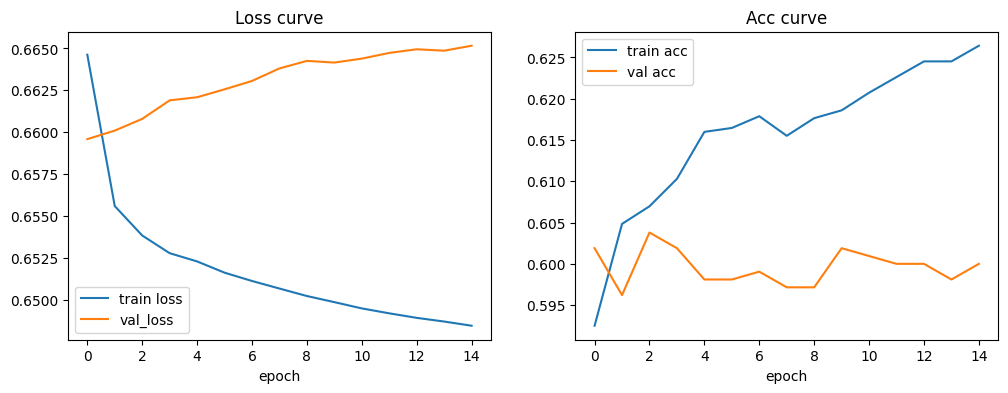

In [128]:
import matplotlib.pyplot as plt

h = history.history

# 一次畫兩張圖並排:subplots(1, 2)代表1列2欄, figsize=(寬, 高)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左圖:Loss曲線，越低代表預測越準
# Loss曲線的兩條線如果都往下並且貼在一起，那是最理想的狀態，如果train線往下走，val往上走，代表過擬和
axes[0].plot(h['loss'], label='train loss')
axes[0].plot(h['val_loss'], label='val_loss')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('epoch')
axes[0].legend()

# 右圖:Accuracy曲線，越高越好
axes[1].plot(h['accuracy'], label='train acc')
axes[1].plot(h['val_accuracy'], label='val acc')
axes[1].set_title('Acc curve')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.show()


---
## 第 6 節　幫模型打分數 —— 並誠實看待結果

模型訓練完,當然要問一句:「它到底準不準?」

但這是整個單元<b>最重要</b>的一節,因為我們<b>不會</b>只看「準確率幾趴」就高興。我們會拿模型去跟一個「最笨的猜法」(永遠猜比較多的那一類)比一比:

如果辛苦訓練的模型連亂猜都贏不過,那就代表資料裡根本沒有訊號。這一步,是在教你<b>誠實地看待結果</b>,而不是被一個好看的數字騙了。

In [129]:
# 在測試集上評估
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'神經網路測試準確率: {test_acc:.3f}')

# Baseline:永遠猜測試集裡面較多的那一類
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'Baseline(永遠只猜同一類): {baseline_acc:.3f}')

# 差多少
print(f'神經網路 - baseline = {test_acc - baseline_acc:.3f}')

神經網路測試準確率: 0.574
Baseline(永遠只猜同一類): 0.511
神經網路 - baseline = 0.063


---
## 第 7 節　把模型存起來、再讀回來

訓練一次要花時間,總不能每次要用就重練一遍。這一節教你把訓練好的模型「存成檔案」,下次直接讀回來就能用。

我們還會存完馬上讀回來、再評分一次,確認存檔過程沒有掉東西——讀回來的準確率,應該和存檔前一模一樣。

In [132]:
# 儲存整個模型(Keras格式)
model.save('u1_mlp_2327.keras')
print('模型已儲存')

# 載回來確認可用
loaded = keras.models.load_model('u1_mlp_2327.keras')
check_loss, check_acc = loaded.evaluate(X_test_s, y_test, verbose=0)
print(f'載入後準確率: {check_acc:.3f} (應與先前相同)')

模型已儲存
載入後準確率: 0.574 (應與先前相同)
